<a href="https://colab.research.google.com/github/ayalaart007-sudo/P03_/blob/main/P03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RECURSOS

Inegrantes:
* Santiago Nava Pulido
* Eugenio Hernández Aranda
* Arturo Ayala Hernández

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns


In [ ]:
pip install scikit-optimize

In [ ]:
pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from skopt import BayesSearchCV
from sklearn.ensemble import BaggingClassifier
from skopt import BayesSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV

In [ ]:
dt = files.upload()

Saving credit_card_fraud_10k.csv to credit_card_fraud_10k.csv


In [ ]:
df = pd.read_csv('credit_card_fraud_10k.csv')

# Detección de Fraude en Tarjetas de Crédito mediante Algoritmos de Ensamble

> Añadir blockquote




## Objetivos

### Generales
*   Desarrollar un modelo predictivo basado en algoritmos de machine learning capaz de clasificar con alta precisión las transacciones de tarjetas de crédito como legítimas o fraudulentas, con el fin último de mitigar el riesgo financiero y reducir las pérdidas operativas.

### Específicos
* Realizar un análisis exploratorio y de ingeniería de características (como la transformación cíclica de la temporalidad) para preparar y limpiar los datos transaccionales.
* Implementar y optimizar pipelines de procesamiento en conjunto con modelos de ensamble (Random Forest y XGBoost).
* Evaluar y comparar el desempeño de los modelos utilizando validación cruzada de k-folds, priorizando la reducción de falsos positivos y falsos negativos en un entorno de datos desbalanceados.

# Marco Teórico

### Regresión Lineal


* 6 Problemas Potenciales en una Regresión (ISLP)

1. Non-Linearity of data
2. Correlation of error terms
3. Non-constant variance od error terms (heterocedasticidad)
4. Outliers
5. High leverage ponits
6. Collinearity

### Árbol para Regresión


*   Un árbol de regresión es un modelo de machine-learning que se encarga de predecir un grupo de datos continuos al dividirlos en grupos más pequeños y específicos usando particiones binarias, algunos de sus componentes son las hojas, la profundiad, las raíces, etc.

### Árbol para Clasificación

*   Es un modelo predictivo que asigna observaciones a clases cualitativas dividiendo el espacio de predictores en regiones (nodos). Utiliza métricas como la entropía o el Índice Gini para maximizar la pureza de cada nodo final, logrando separar las clases de la forma más limpia posible.

### Bootstrap

*   Técnica de remuestreo estadístico que consiste en extraer múltiples muestras aleatorias (con reemplazo) a partir del conjunto de datos original. Se utiliza para cuantificar la incertidumbre de un estimador o para proporcionar diferentes conjuntos de entrenamiento en modelos complejos.

### Ensambles de Modelos

*   Metodología que combina las predicciones de múltiples modelos base (usualmente más simples) para construir un modelo final predictivo más robusto, preciso y estable, reduciendo tanto la varianza como el sesgo.

#### Bagging

*   Construye múltiples copias independientes del modelo original utilizando distintas muestras bootstrap y promedia sus predicciones (o usa voto mayoritario). Su objetivo principal es reducir la varianza sin aumentar el sesgo (ej. Random Forest).

#### Boosting

*   Construye modelos de forma secuencial, donde cada nuevo árbol intenta corregir los errores cometidos por la secuencia de árboles anteriores. A diferencia del Bagging, aprende paso a paso para reducir drásticamente el sesgo predictivo (ej. XGBoost).


James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023)

# Tema Elegido para Proyecto y Análisis de Dataset

## Tema Elegido

*   Modelado Predictivo para la Detección de Transacciones Financieras Fraudulentas.

## Análisis de Dataset


#### ¿De dónde viene?

*   El conjunto de datos "Credit Card Fraud Detection Dataset" fue obtenido del repositorio público de Kaggle.

#### ¿Qué contiene?

*   Está compuesto por 10,000 registros y 10 variables (numéricas, categóricas y binarias), abarcando información como el identificador de la transacción, el monto de dinero, la hora, la categoría del comercio, características de ubicación geográfica y el perfil de confianza del dispositivo.

#### ¿Qué información dan las muestras?

*   Cada fila representa una operación individual con tarjeta de crédito. Refleja tanto el contexto de la compra (qué se compró, cuándo y desde dónde) como indicadores del comportamiento del usuario (velocidad de transacción en las últimas 24 horas y edad), etiquetadas con un '1' si resultaron ser fraude y '0' si fueron legítimas.

#### ¿Qué se quiere analizar?

*   Se busca encontrar las dependencias ocultas y los patrones no lineales que diferencian el comportamiento de consumo habitual frente a un ataque de fraude.
#### ¿Qué resultado se podría encontrar al ajustar un modelo?

*  Se espera que el modelo confirme que ciertas combinaciones de variables (como montos atípicamente altos a horas de la madrugada, sumados a una discordancia de ubicación) son fuertes predictores de fraude. Ajustar el modelo correctamente nos permitirá identificar el fraude con un alto nivel de "Precision", superando el reto que impone el desbalance de las clases.

<small>*Este conjunto de datos se ha generado sintéticamente y no contiene datos reales de clientes.*</small>

##PIPELINES
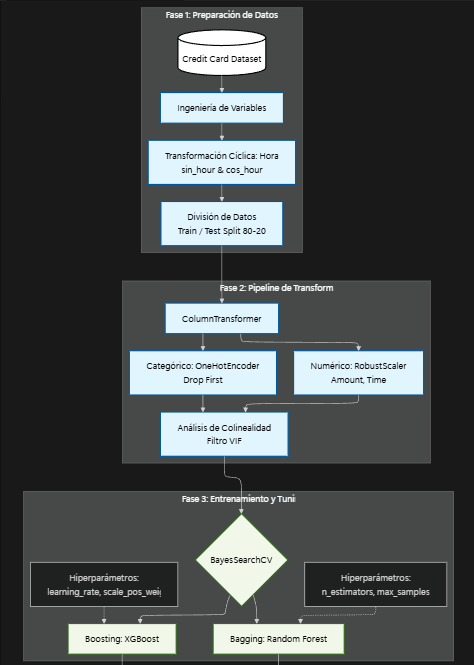
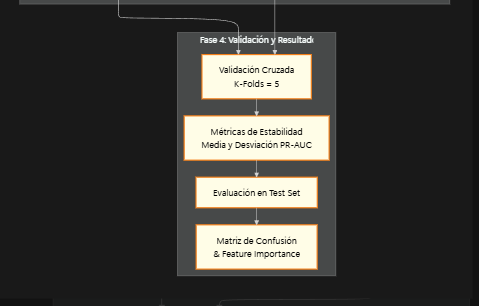


## EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
df.head(1)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0


In [ ]:
#from pandas_profiling import ProfileReport
#profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
#profile.to_notebook_iframe()
#profile.to_file("eda_fraude_reporte.html")

* GITHUB no es compatible con este EDA ya que genera un reporte HTML, se anexará al repositorio, aqui los hallazagos clave:

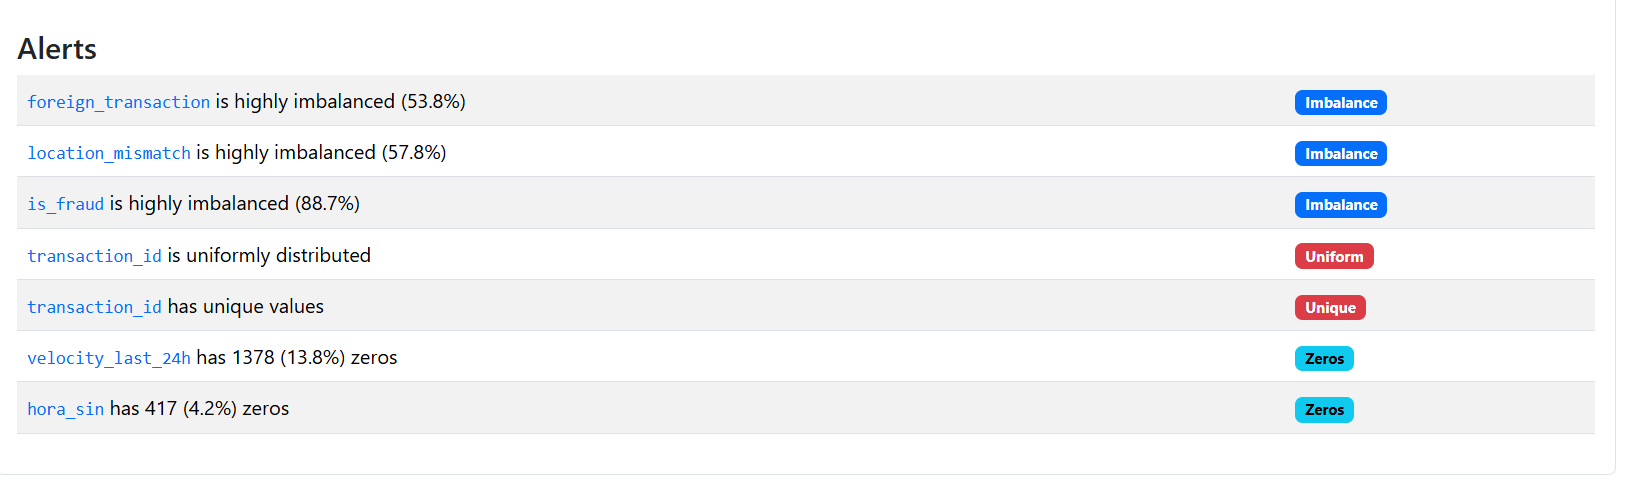

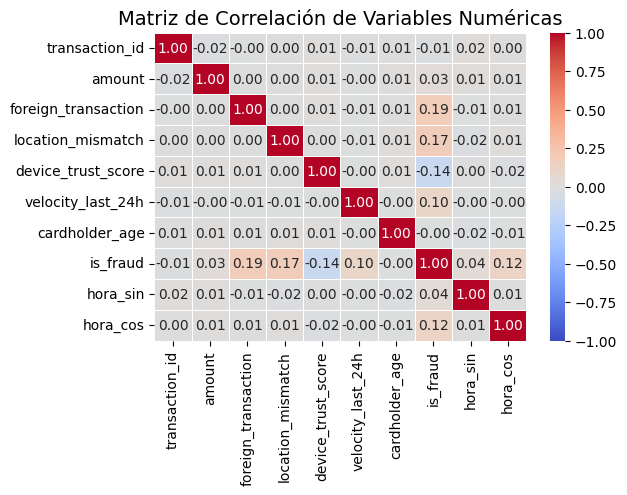

In [ ]:
#matriz de correlación
plt.figure(figsize=(6, 4))
df_numerico = df.select_dtypes(include=[np.number])
correlacion = df_numerico.corr()

sns.heatmap(correlacion, annot=True,  cmap='coolwarm', fmt=".2f",linewidths=0.5,vmin=-1, vmax=1)

plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14)
plt.show()

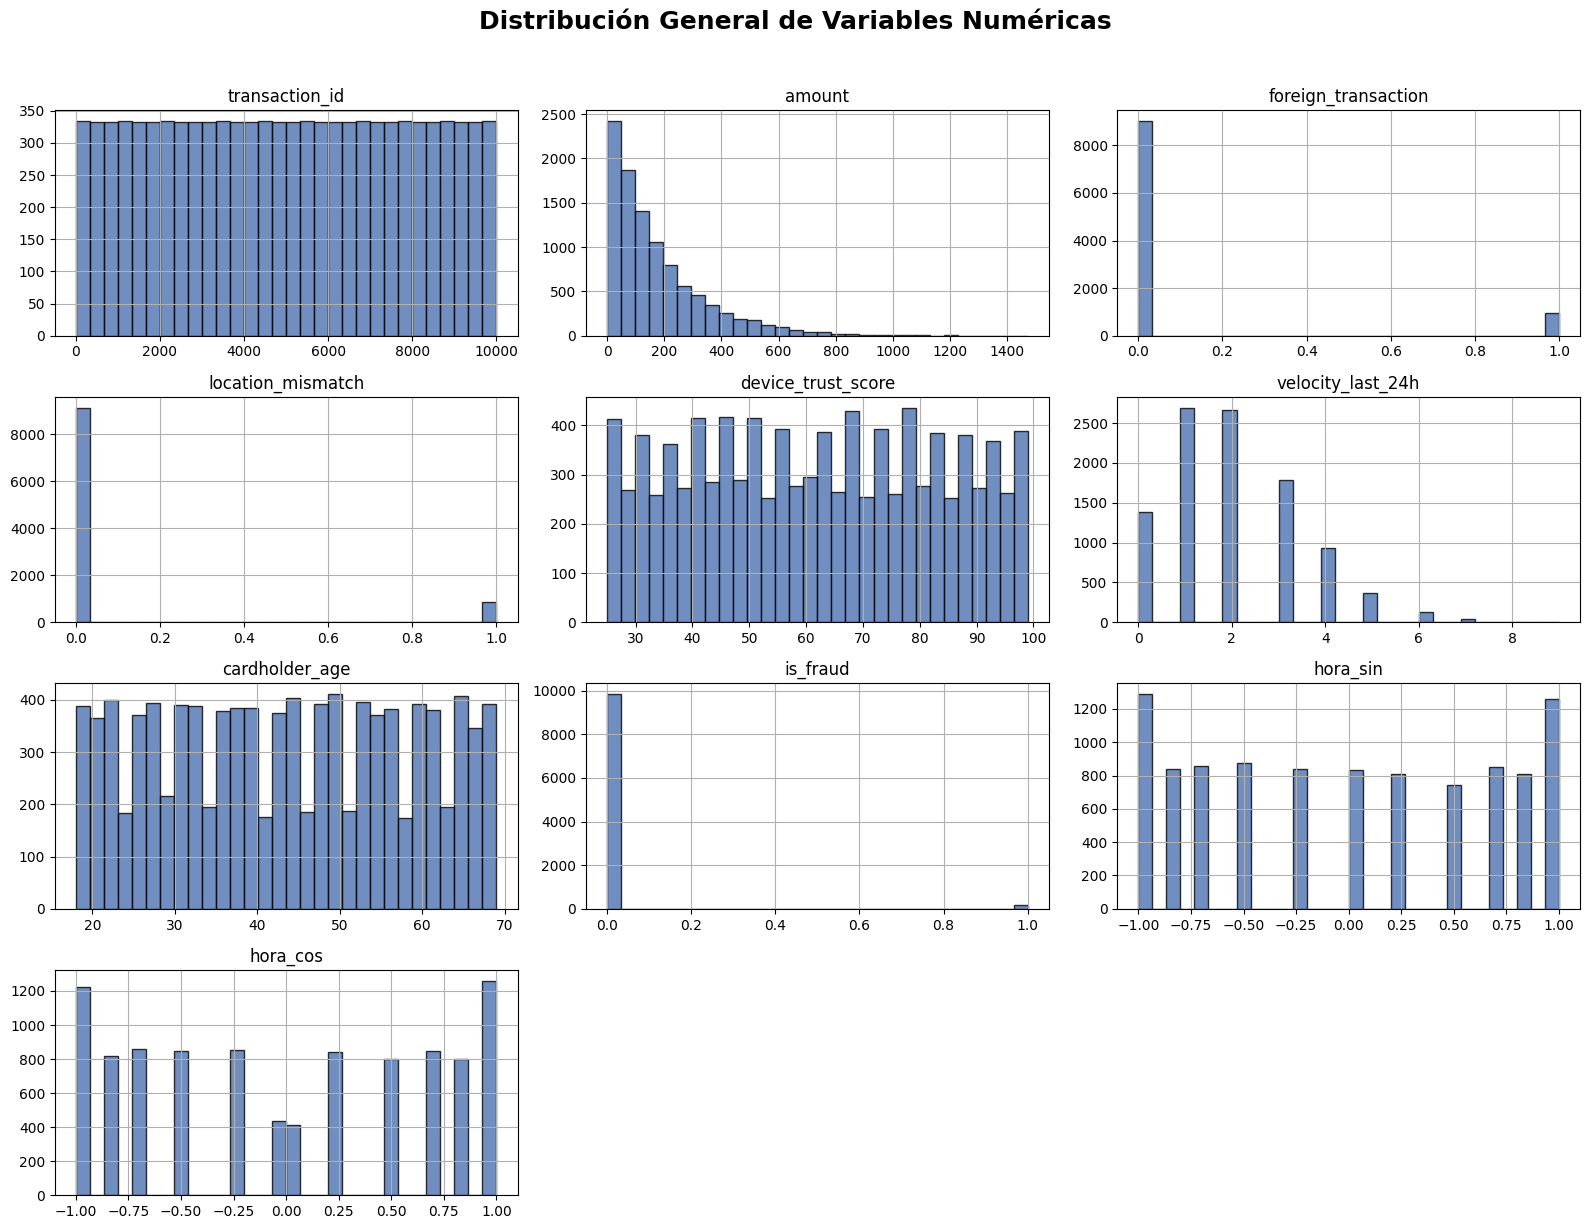

In [ ]:

df.hist(figsize=(16, 12),
        bins=30,
        color='#4C72B0',
        edgecolor='black',
        grid=True,
        alpha=0.8)

plt.suptitle('Distribución General de Variables Numéricas', fontsize=18, y=1.02, fontweight='bold')

plt.tight_layout()
plt.show()

Observaciones:
* Poseemos una desbalance significativo en la variable a predecir (is_fraud) lo cual no llevara a enfocarnos a la calidad de respuesta de fraude y en metricos que nos pemitan conocer el desempeño de froma más especifica.

* Existe un desbalance en el numero de transacciones diarias (muchos 0), igualmente en "foreign_transaction" y "location_mismatch",sin embargo no se eliminarán  ya que posee una alta correlación con los fraudes.

* Se requerirá  trabajar con el fromato de las hora de transacción, tal vez a un fromato ciclico.



## ING. CARACTERÍSTICAS

In [ ]:
df.tail(1)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


Transformaremos "transaction_hour" a una vatiable ciclica para mantener periodicidad y el hecho de que 0 y 23 deben ser cercanas

* hora_sin=sin(2π/24h)
* hora_cos=cos(2π/24h)



In [ ]:
df['hora_sin'] = np.sin(2*np.pi*df['transaction_hour']/24)
df['hora_cos'] = np.cos(2*np.pi*df['transaction_hour']/24)

df.drop('transaction_hour', axis=1, inplace=True)

Determinamos tipos de datos, columnas a trabajar y su procesamiento

In [ ]:
df_clean = df.drop(columns='transaction_id')

In [ ]:
num_cols = ['amount', 'velocity_last_24h', 'cardholder_age', 'device_trust_score']
cat_cols = ['merchant_category']
bin_cols = ['foreign_transaction', 'location_mismatch','hora_cos', 'hora_sin']

In [ ]:
X = df[cat_cols + num_cols + bin_cols]
Y = df['is_fraud']

In [ ]:
#los procesos que usaremos
num_transformer = RobustScaler() #preferimos usar esta librería debido al comportamiento de las variables
cat_transformer = OneHotEncoder(drop='first')

In [ ]:
preprocesor = ColumnTransformer(transformers=[('num',num_transformer,num_cols), ('cat', cat_transformer, cat_cols),('bin', 'passthrough', bin_cols)])

### ANALISIS DE COLINEALIDAD (VIF)
Aprobechando el preprocesador realizaremos un analisis de nuestras variables para analisar si alguna es redundante

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def calcular_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    # Calculamos el VIF para cada columna
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
    for i in range(len(X.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

procesados = preprocesor.fit_transform(X)
feature_names = preprocesor.get_feature_names_out()
procesados_df = pd.DataFrame(procesados, columns=feature_names)

vif_df = calcular_vif(procesados_df)
print(vif_df)

                               feature       VIF
8             bin__foreign_transaction  1.088629
9               bin__location_mismatch  1.076609
0                          num__amount  1.075038
5          cat__merchant_category_Food  1.063280
4   cat__merchant_category_Electronics  1.057680
7        cat__merchant_category_Travel  1.057161
6       cat__merchant_category_Grocery  1.052070
2                  num__cardholder_age  1.002070
10                       bin__hora_cos  1.001638
3              num__device_trust_score  1.001537
11                       bin__hora_sin  1.001332
1               num__velocity_last_24h  1.000358


Confirmamos que los datos son lienalmente independientes y prorporcionan información unica

### dividimos en train - test

In [ ]:
train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=0.4, random_state=42)

In [ ]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 9761 to 7270
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   merchant_category    6000 non-null   object 
 1   amount               6000 non-null   float64
 2   velocity_last_24h    6000 non-null   int64  
 3   cardholder_age       6000 non-null   int64  
 4   device_trust_score   6000 non-null   int64  
 5   foreign_transaction  6000 non-null   int64  
 6   location_mismatch    6000 non-null   int64  
 7   hora_cos             6000 non-null   float64
 8   hora_sin             6000 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 468.8+ KB


# Modelo Propuesto
* Random Forest para Clasificació
*  XGBoost para Clasificación
* Optimización de Hiperparámetros




## Random Forest Regressor (BAGGING)

In [ ]:
#preprocesamos el test
test_x_procesado = preprocesor.transform(test_x)


In [ ]:
RFR = RandomForestClassifier(random_state=42)
model = BaggingClassifier(estimator=RFR, n_estimators=50, random_state=42)


In [ ]:
pipeline_RFR = Pipeline(steps=[('preprocesor', preprocesor), ('MODEL', model)])

Optimizamos los hiperparametros...

In [ ]:
parametros = {
    'MODEL__n_estimators': (50, 100), #numero de arboles
    'MODEL__max_samples': (0.5, 1.0), #cantidad de datos que realizara el bootstrap
    'MODEL__estimator__max_depth': (2, 20), #profundidad de los arboles
    'MODEL__estimator__class_weight': ['balanced', 'balanced_subsample'] #pesos en base a los conjuntos o por cada subconjunto
}


In [ ]:
#optimizamos con Bayes
opt = BayesSearchCV(
    estimator = pipeline_RFR,
    search_spaces=parametros,
    cv=3,
    n_iter=12,
    n_jobs=-1,
    scoring = 'average_precision',
    random_state=42
)

opt.fit(train_x, train_y)

BayesSearchCV(cv=3,
              estimator=Pipeline(steps=[('preprocesor',
                                         ColumnTransformer(transformers=[('num',
                                                                          RobustScaler(),
                                                                          ['amount',
                                                                           'velocity_last_24h',
                                                                           'cardholder_age',
                                                                           'device_trust_score']),
                                                                         ('cat',
                                                                          OneHotEncoder(drop='first'),
                                                                          ['merchant_category']),
                                                                         ('bin',
                                                                          'passthrough',
                                                                          ['foreign_transaction',
                                                                           'location_mismatch',
                                                                           'hora_cos',
                                                                           'hora_sin'])])),
                                        ('MODEL',
                                         BaggingClassifier(estimator=RandomForestClassifier(random_state=42),
                                                           n_estimators=50,
                                                           random_state=42))]),
              n_iter=12, n_jobs=-1, random_state=42,
              scoring='average_precision',
              search_spaces={'MODEL__estimator__class_weight': ['balanced',
                                                                'balanced_subsample'],
                             'MODEL__estimator__max_depth': (2, 20),
                             'MODEL__max_samples': (0.5, 1.0),
                             'MODEL__n_estimators': (50, 100)})

In [ ]:
from sklearn.metrics import precision_score
#analizamos rapidamente un resultado usando test
model_final = opt.best_estimator_
predictions = model_final.predict(test_x)
precision = precision_score(test_y, predictions)
print(f"Precision Score: {precision:.4f}")

Precision Score: 1.0000


###Mejora relativa que aporta cada variable al modelo al reducir la impureza en los nodos

In [ ]:

bagging_model = model_final.named_steps['MODEL']
sum_importances = np.zeros(bagging_model.estimators_[0].feature_importances_.shape) #obtenemos las importancias

#promediamos la reducción de impurezas
for estimator in bagging_model.estimators_:
    sum_importances += estimator.feature_importances_
average_importances_rf = sum_importances / len(bagging_model.estimators_)

#mapeamos los nombresde las columnas
X_procesadas = model_final.named_steps['preprocesor'].get_feature_names_out()
feature_importance_rf = pd.DataFrame({
    'Feature': X_procesadas,
    'Importance': average_importances_rf
}).sort_values(by='Importance', ascending=True)

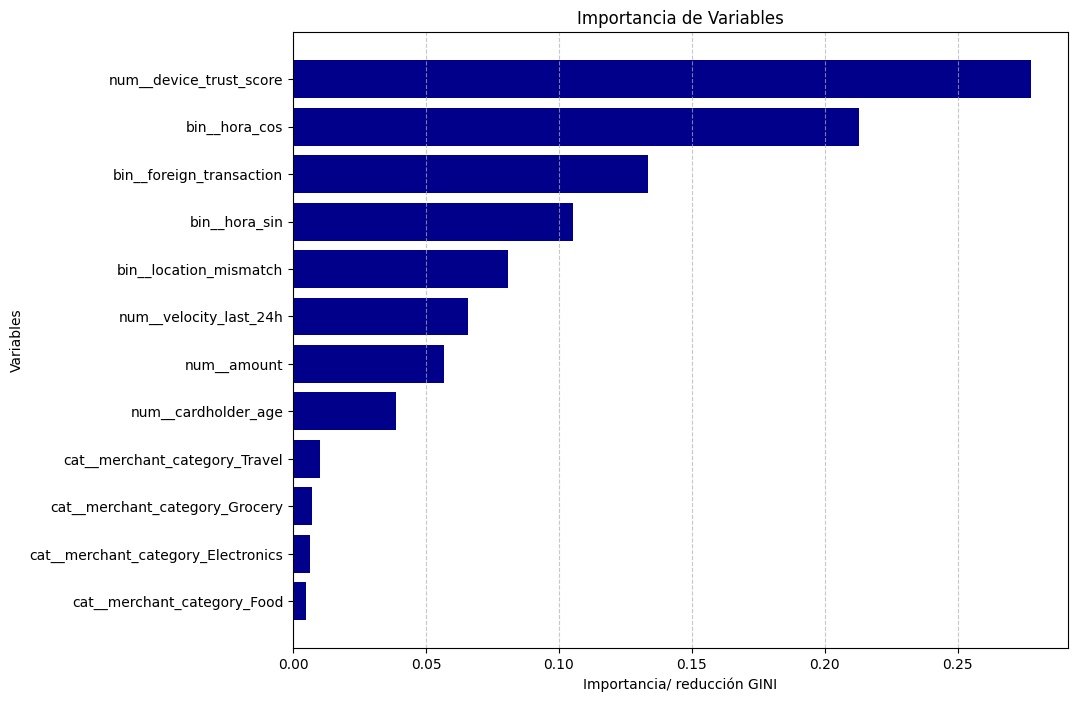

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], color='darkblue')
plt.xlabel('Importancia/ reducción GINI')
plt.ylabel('Variables')
plt.title('Importancia de Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Comportamiento de los errores

## MODELO XGBOOST

In [ ]:
modelo_2 = XGBClassifier(random_state=42, verbosity=0,use_label_encoder=False)
pipeline_XGB = Pipeline(steps=[('preprocesor', preprocesor),
 ('MODEL', modelo_2)])

Optimizamos

In [ ]:
parametros_xgb = {
    'MODEL__n_estimators': (50, 300),          # Cantidad de iteraciones de boosting
    'MODEL__learning_rate': (0.01, 0.2, 'log-uniform'), # Ritmo de aprendizaje
    'MODEL__max_depth': (3, 7),               # Árboles poco profundos para evitar overfitting
    'MODEL__subsample': (0.6, 0.9),           # Porcentaje de datos por árbol para dar varianza
    'MODEL__colsample_bytree': (0.5, 0.8),    # Fracción de columnas (features) por árbol
    'MODEL__scale_pos_weight': (50, 150),     # Penalización al error en fraude (ajustar según desbalance)
    'MODEL__gamma': (0, 5),                   # Regularización: reducción mínima de pérdida para dividir
    'MODEL__reg_alpha': (1e-5, 10, 'log-uniform') # Regularización L1

}

In [ ]:
opt_xgb = BayesSearchCV(
    pipeline_XGB,
    parametros_xgb,
    n_iter=30,
    cv=5,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Ajuste con el set de entrenamiento
opt_xgb.fit(train_x, train_y)

BayesSearchCV(cv=5,
              estimator=Pipeline(steps=[('preprocesor',
                                         ColumnTransformer(transformers=[('num',
                                                                          RobustScaler(),
                                                                          ['amount',
                                                                           'velocity_last_24h',
                                                                           'cardholder_age',
                                                                           'device_trust_score']),
                                                                         ('cat',
                                                                          OneHotEncoder(drop='first'),
                                                                          ['merchant_category']),
                                                                         ('bin',
                                                                          'passthrough',
                                                                          ['foreign_transaction',
                                                                           'location_mismatch',
                                                                           'hora_cos',
                                                                           'hora_sin'])])),
                                        ('MODEL',
                                         XGBClass...
                                                       num_parallel_tree=None, ...))]),
              n_iter=30, n_jobs=-1, random_state=42,
              scoring='average_precision',
              search_spaces={'MODEL__colsample_bytree': (0.5, 0.8),
                             'MODEL__gamma': (0, 5),
                             'MODEL__learning_rate': (0.01, 0.2, 'log-uniform'),
                             'MODEL__max_depth': (3, 7),
                             'MODEL__n_estimators': (50, 300),
                             'MODEL__reg_alpha': (1e-05, 10, 'log-uniform'),
                             'MODEL__scale_pos_weight': (50, 150),
                             'MODEL__subsample': (0.6, 0.9)})

In [ ]:
modelo_final_2 = opt_xgb.best_estimator_
predictions = modelo_final_2.predict(test_x)
precision = precision_score(test_y, predictions)
print(f"Precision Score: {precision:.4f}")

Precision Score: 1.0000


###Mejora relativa que aporta cada variable al modelo al reducir la impureza en los nodos

In [ ]:

best_xgb_model = opt_xgb.best_estimator_.named_steps['MODEL']
importancias_map = best_xgb_model.get_booster().get_score(importance_type='gain')

# XGBoost asigna f# así qye tenemos que conseguir los nombres reales
nombres_limpios = opt_xgb.best_estimator_.named_steps['preprocesor'].get_feature_names_out()
importancias_con_nombres = {
    nombres_limpios[int(k[1:])]: v for k, v in importancias_map.items()
}

df_importancia = pd.DataFrame(
    list(importancias_con_nombres.items()),
    columns=['Feature', 'Gain']
).sort_values(by='Gain', ascending=True)

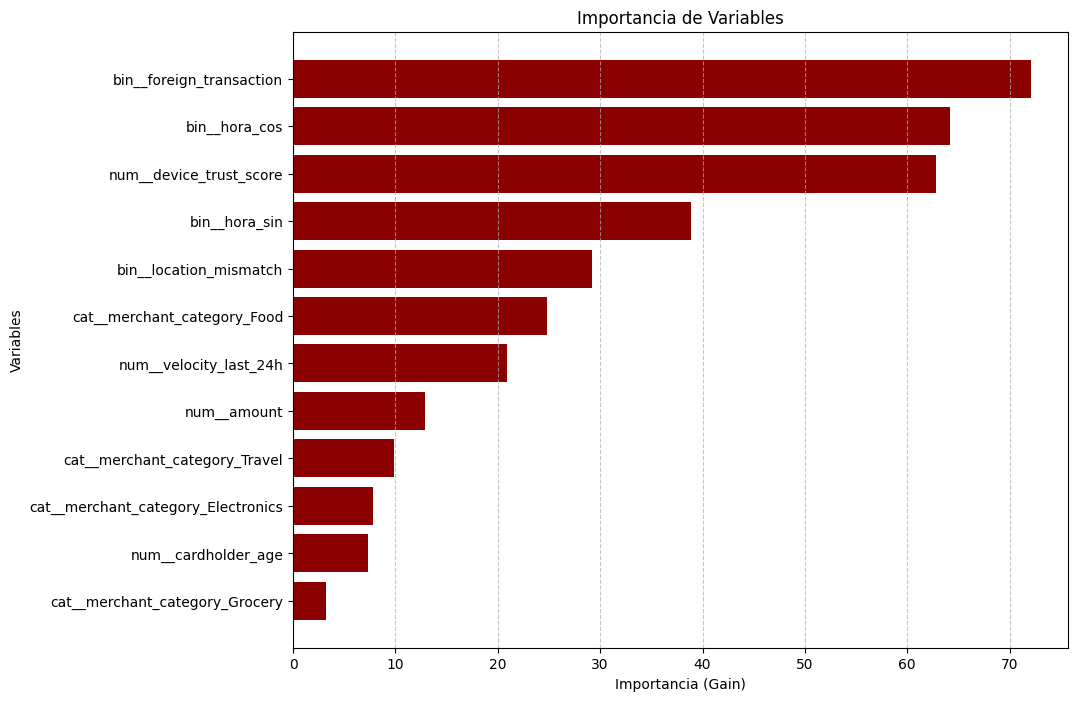

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(df_importancia['Feature'], df_importancia['Gain'], color='darkred')
plt.xlabel('Importancia (Gain)')
plt.ylabel('Variables')
plt.title('Importancia de Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Pipeline

# Ajuste de Modelos con Comparaciones del Métrico Elegido

* Ajuste y Evaluación


* Métrico Elegido


* Comparación de Modelos


RESULTADO RANDOM  FOREST

In [ ]:
scores_train_RF = cross_val_score(model_final, train_x, train_y, cv=5, scoring='precision')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(f"Pr Medio: {scores_train_RF.mean():.4f}")
print(f"Desviación Estándar: {scores_train_RF.std():.4f}")

Pr Medio: 0.8000
Desviación Estándar: 0.4000


notamos que el modelos posee excesiva varianza la cual lo vuelve poco confiable, sin embargo el precisión promedio es bueno.

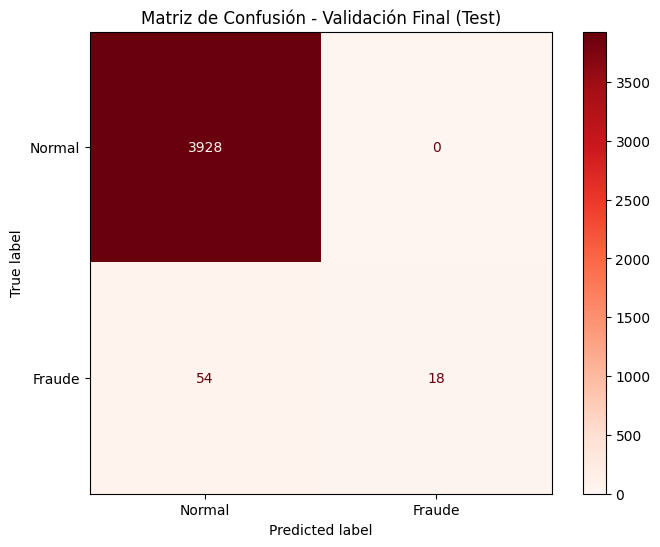

In [ ]:
y_pred = model_final.predict(test_x)

cm = confusion_matrix(test_y, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
disp.plot(cmap='Reds', ax=ax)
plt.title('Matriz de Confusión - Validación Final (Test)')
plt.show()

In [ ]:
acc = accuracy_score(test_y, y_pred)
prec = precision_score(test_y, y_pred)
rec = recall_score(test_y, y_pred)
f1 = f1_score(test_y, y_pred)
error = 1 - acc

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Error: {error:.4f}")

Accuracy: 0.9865
Precision: 1.0000
Recall: 0.2500
F1 Score: 0.4000
Error: 0.0135


Distinguiendo las decisiones dentro de la matriz de confusión y los metricos, nuestro modelo aunque posee un precisión perfecto no detecto practicamente 75% de los fraudes los cual no empata con el objetivo que buscabamos.

RESULTADO DE XGBOOST

In [ ]:
scores_test_RF = cross_val_score(modelo_final_2, train_x, train_y, cv=5, scoring='precision')

In [ ]:
print(scores_test_RF.mean())
(scores_test_RF.std())

0.9714285714285715


np.float64(0.03499271061118824)

Al contrario de bagging, boosting consiguio de forma muy consitente (desviación +- .034) teniendo un precissión de .97, lo cual nos hable de un modelo muy  seguro de sus decisiones.

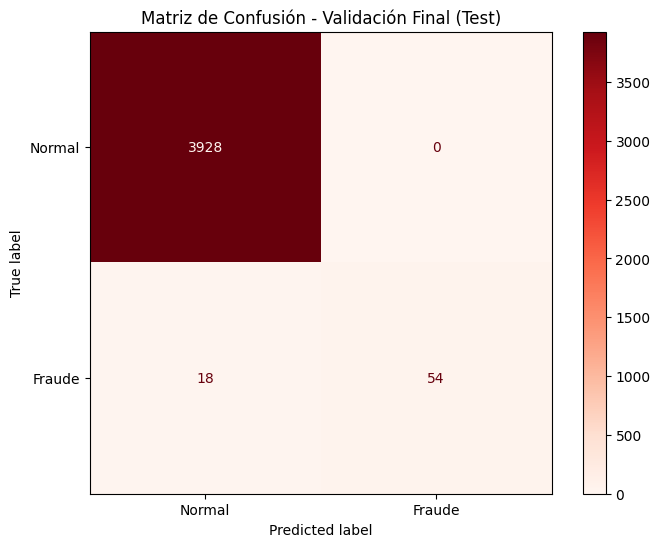

In [ ]:
y_pred = modelo_final_2.predict(test_x)

cm = confusion_matrix(test_y, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
disp.plot(cmap='Reds', ax=ax)
plt.title('Matriz de Confusión - Validación Final (Test)')
plt.show()

In [ ]:
acc = accuracy_score(test_y, y_pred)
prec = precision_score(test_y, y_pred)
rec = recall_score(test_y, y_pred)
f1 = f1_score(test_y, y_pred)
error = 1 - acc

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Error: {error:.4f}")

Accuracy: 0.9955
Precision: 1.0000
Recall: 0.7500
F1 Score: 0.8571
Error: 0.0045


Poseemos un modelo muy confiable con precision practicamente perfecto y además identificando el 75% de los fraudes que sucedieron en este fragmento del dataset.

# Conclusión
<!-- Las conclusiones deben ser específicas y responder a los objetivos planteados, basándose en los resultados obtenidos del análisis y modelado. -->

Los resultados concluyen que XGBoost es la arquitectura óptima para la detección confiable de fraudes crediticios. Su desempeño superó consistentemente al de Bagging, logrando una precisión superior con una varianza mínima en las pruebas de validación cruzada. Por el contrario, se desaconseja el uso de Bagging para esta problemática específica, debido a su elevada inestabilidad y a su limitada capacidad para identificar correctamente los patrones de fraude en entornos de alta complejidad.​

## Referencias
<!-- Listado de todas las fuentes consultadas, siguiendo el formato APA. -->

Elserty, A. (2020). Credit Card Fraud Detection Dataset [Conjunto de datos]. Kaggle. https://www.kaggle.com/code/abdelazizelserty/credit-card-fraud-detection-dataset


James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer.

